# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [2]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [3]:
df.info()
#Transformando income em um float
df['Income'] = df['Income'].str.replace('.','').str.replace(',','', regex=False)
df['Income'] = df['Income'].astype(float)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    object 
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 10.4+ KB


In [4]:
#Testando se mudou
df.dtypes

Age                   float64
Gender                 object
Income                float64
Education              object
Marital Status         object
Number of Children      int64
Home Ownership         object
Credit Score           object
dtype: object

**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [5]:
#Verificando se existem colunas faltantes
df.isnull().sum()

Age                   34
Gender                 0
Income                 0
Education              0
Marital Status         0
Number of Children     0
Home Ownership         0
Credit Score           0
dtype: int64

In [6]:
#Verificando quantos % age representa no nosso df para saber se excluimos ou preenchemos
(df.isnull().sum() / len(df)) * 100

Age                   20.731707
Gender                 0.000000
Income                 0.000000
Education              0.000000
Marital Status         0.000000
Number of Children     0.000000
Home Ownership         0.000000
Credit Score           0.000000
dtype: float64

In [7]:
#Verificando media e mediana
df['Age'].mean()

np.float64(37.50769230769231)

In [8]:
df['Age'].median()

36.0

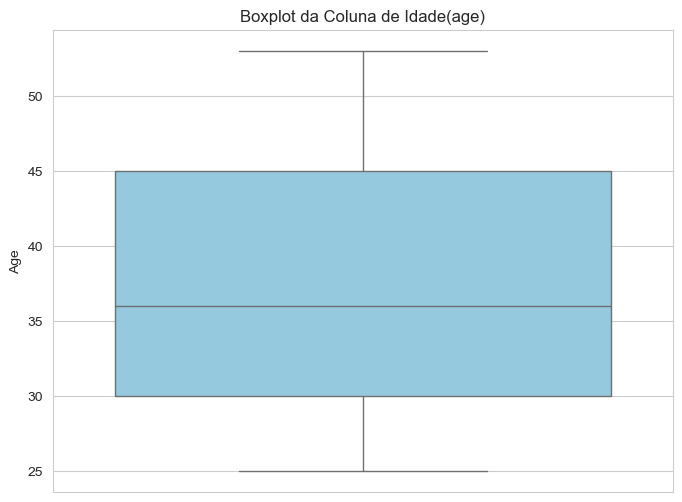

In [9]:
#Verificando possiveis outliers já que a media e mediana estão proximas
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Age', color='skyblue')
plt.title('Boxplot da Coluna de Idade(age)')
plt.ylabel('Age')
plt.show()

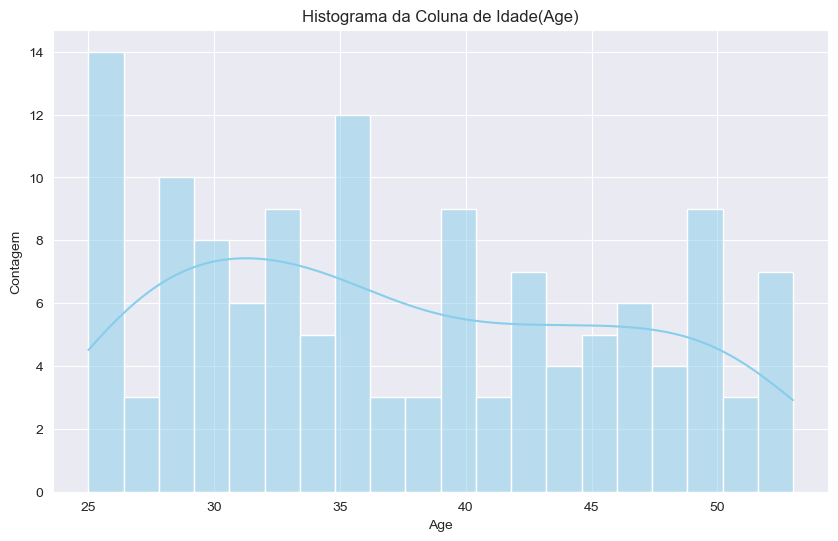

In [10]:
#Histograma para entender melhor a distribuição dos dados
sns.set_style('darkgrid')


plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', bins=20, kde=True, color='skyblue')
plt.title('Histograma da Coluna de Idade(Age)')
plt.xlabel('Age')
plt.ylabel('Contagem')
plt.show()

In [11]:
#Identificamos outliers em idade abaixo de 25 então iremos calculas uma mediana sem esses numeros
idade_acima_25 = df[df['Age'] > 25]
idade_acima_25['Age'].median()

37.0

In [12]:
#Preenchendo as idades faltantes com a mediana da idade sem as idades abaixo de 25 anos
mediana_idade_acima_25 = idade_acima_25 = df[df['Age'] > 25]['Age'].median()
df['Age'] = df['Age'].fillna(mediana_idade_acima_25)

### Escolhi por substituir os numeros faltantes da idade por representarem 20% dos nossos valores totais e ser um elemento chave para futuras análises

**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [13]:
#seu código aqui
df.head()

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,5000000.0,Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,10000000.0,Master's Degree,Married,2,Owned,High
2,35.0,Female,7500000.0,Doctorate,Married,1,Owned,High
3,40.0,Male,12500000.0,High School Diploma,Single,0,Owned,High
4,45.0,Female,10000000.0,Bachelor's Degree,Married,3,Owned,High


In [ ]:
#Verificando colunas categoricas se existem erros de digitação
#Genero
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [15]:
#Estado Civil
df['Marital Status'].unique()

array(['Single', 'Married'], dtype=object)

In [16]:
# Se é dono da propria casa ou alugada
df['Home Ownership'].unique()

array(['Rented', 'Owned'], dtype=object)

In [17]:
#Score de credito
df['Credit Score'].unique()

array(['High', 'Average', 'Low'], dtype=object)

### Nas Verificações não foram encontrados valores digitados incorretamente

# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [18]:
#seu código aqui
df.describe()

,Age,Income,Number of Children
count,164.000000,1.640000e+02,164.000000
mean,37.402439,8.376524e+06,0.652439
std,7.564625,3.245731e+06,0.883346
min,25.000000,2.500000e+06,0.000000
25%,31.750000,5.750000e+06,0.000000
50%,37.000000,8.375000e+06,0.000000
75%,43.000000,1.050000e+07,1.000000
max,53.000000,1.625000e+07,3.000000


### Notamos que mesmo havendo uma grande distancia das idades elas continuam dentro dos limites sem a presença de outliers

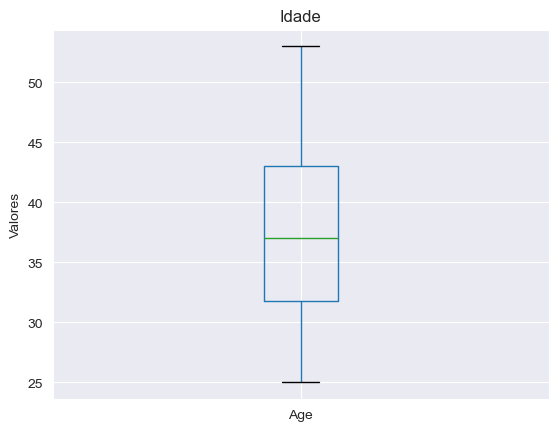

In [19]:
#Analisando as idades para ver uma possivel presença de outliers
df.boxplot(column='Age')
plt.title('Idade')
plt.ylabel('Valores')
plt.show()

### Na renda podemos perceber que mesmo a maioria dos valores se encontrando abaixo da média também não possuem outliers se encaixando nos limites

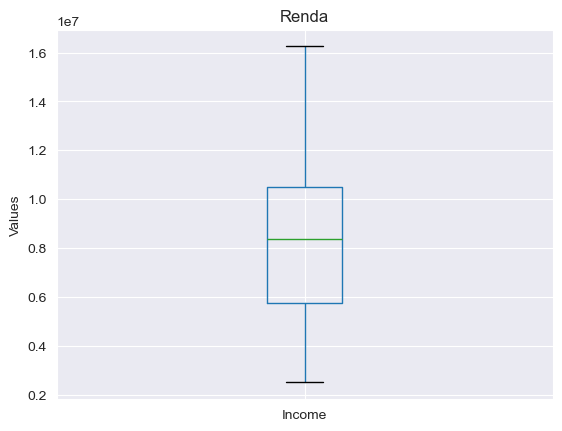

In [20]:
df.boxplot(column= 'Income')
plt.title('Renda')
plt.ylabel('Values')

plt.show()

### 3 Aparece como um outlier em numero de filhos mas como a contagem é pequena apenas 0(nenhum),1,2 ou 3 filhos podemos desconsiderar

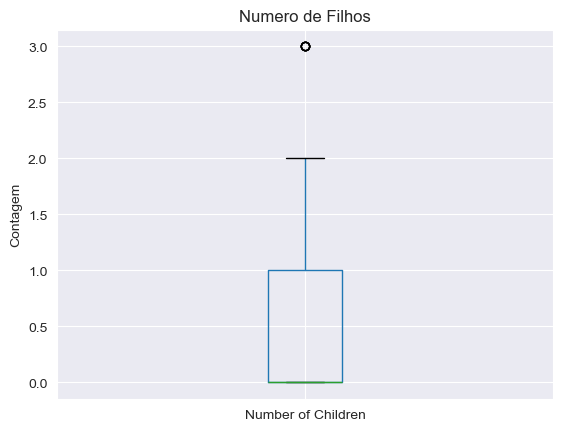

In [21]:
df.boxplot(column='Number of Children')
plt.title('Numero de Filhos')
plt.ylabel('Contagem')

plt.show()

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

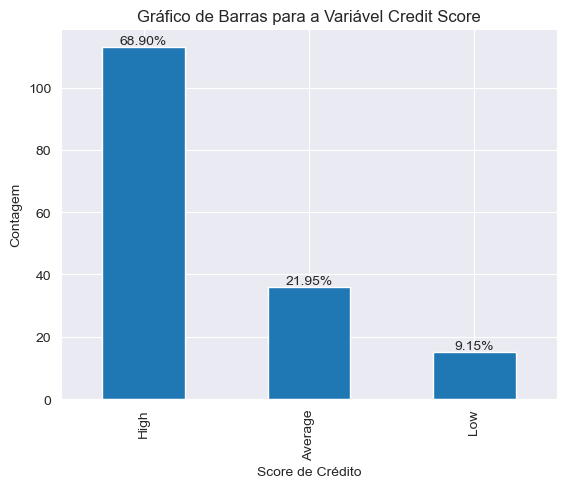

In [ ]:
#seu código aqui
#Credit Score
contagem = df['Credit Score'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100


ax = contagem.plot(kind='bar')
for i, v in enumerate(contagem):
    label = f'{porcentagem.iloc[i]:.2f}%'
    ax.text(i, v + 1, label, ha='center')

plt.title('Gráfico de Barras para a Variável Credit Score')
plt.xlabel('Score de Crédito')
plt.ylabel('Contagem')

plt.show()

### Podemos notar que a grande maioria dos nossos clientes possui um score de crédito alto cerca de 68%.

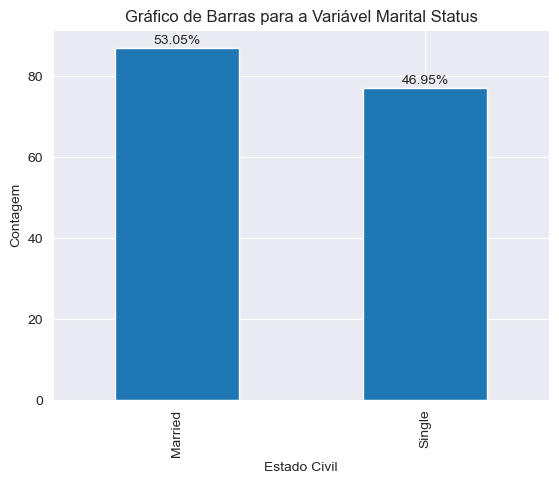

In [ ]:
#Marital Status
contagem = df['Marital Status'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100


ax = contagem.plot(kind='bar')
for i, v in enumerate(contagem):
    label = f'{porcentagem.iloc[i]:.2f}%'
    ax.text(i, v + 1, label, ha='center')

plt.title('Gráfico de Barras para a Variável Marital Status')
plt.xlabel('Estado Civil')
plt.ylabel('Contagem')

plt.show()

### Apesar de proximos podemos ver uma maioria de pessoas casadas do que solteiras

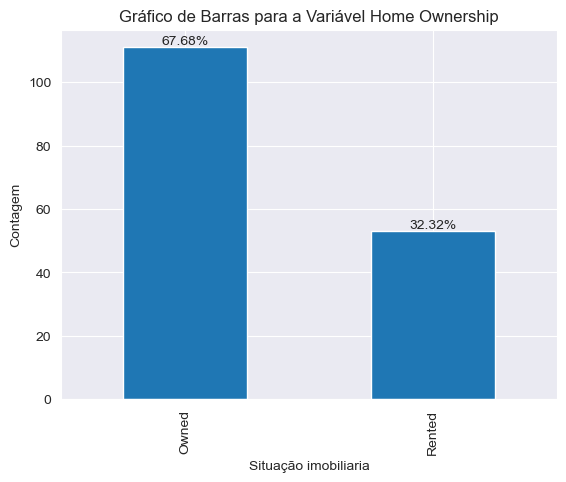

In [ ]:
# Home Ownership
contagem = df['Home Ownership'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100


ax = contagem.plot(kind='bar')
for i, v in enumerate(contagem):
    label = f'{porcentagem.iloc[i]:.2f}%'
    ax.text(i, v + 1, label, ha='center')

plt.title('Gráfico de Barras para a Variável Home Ownership')
plt.xlabel('Situação imobiliaria')
plt.ylabel('Contagem')

plt.show()

### Neste gráfico podemos visualizar que a grande maioria possuia casa propria

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

### De Acordo com as analises não foram encontrados outliers apesar de algumas colunas com valores muito distribuidos

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



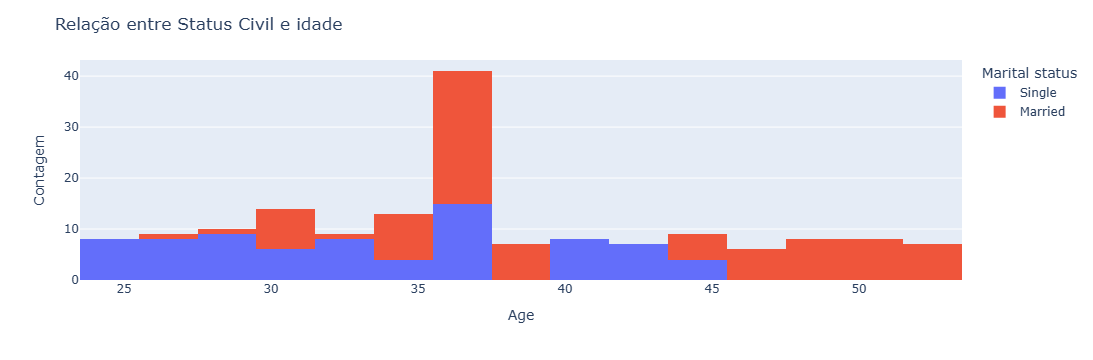

In [ ]:
#seu código aqui
# a) Estado civil e idade
fig = px.histogram(df, x='Age', color='Marital Status', barmode='stack')

fig.update_layout(title='Relação entre Status Civil e idade',
                  xaxis_title='Age',
                  yaxis_title='Contagem',
                  legend_title='Marital status')

fig.show()

### Existe uma relação sim entre o estado civil e a idade mostrando a maioria das pessoas mais velhas como casadas

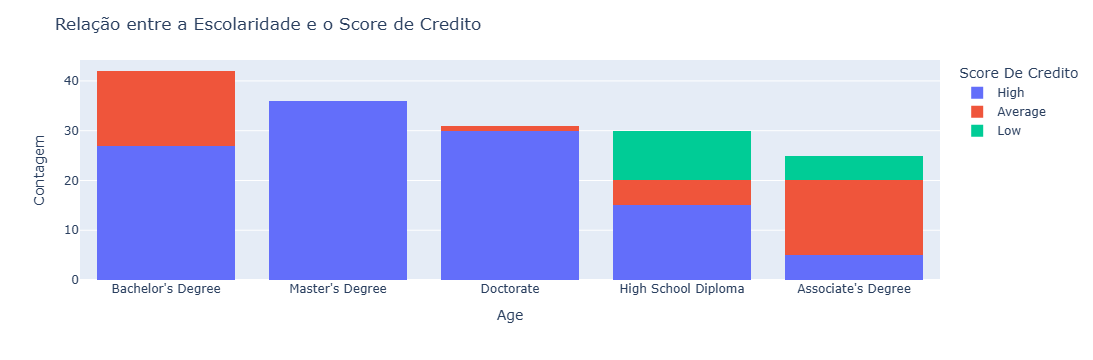

In [ ]:
# b) Nivel de Escolaridade e Score de Credito
fig = px.histogram(df, x='Education', color='Credit Score', barmode='stack')

fig.update_layout(title='Relação entre a Escolaridade e o Score de Credito',
                  xaxis_title='Age',
                  yaxis_title='Contagem',
                  legend_title='Score De Credito')

fig.show()

### Podemos notar que a maior parte das pessoas que possuem um credit Score alto também possuem um nivel de escolaridade mais elevado

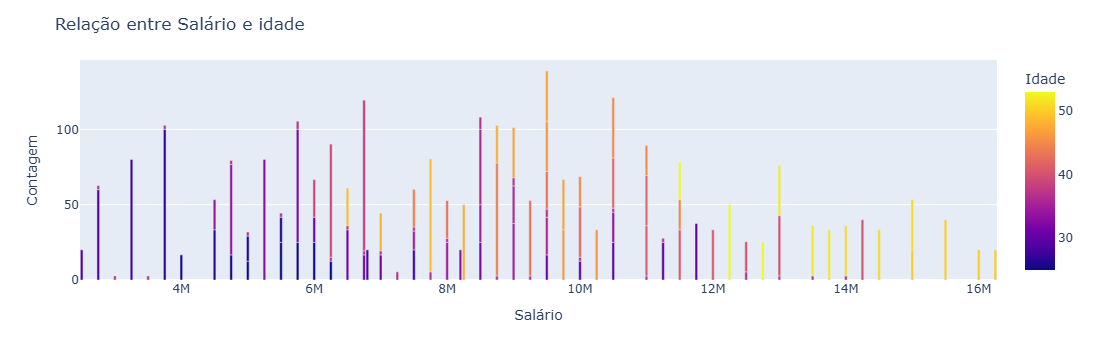

In [ ]:
# C) Salario e idade
df_grouped = df.groupby(['Income', 'Age']).size().reset_index(name='count')
total_por_idade = df_grouped.groupby('Age')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_idade) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Income', y='percent', color='Age', barmode='stack',
             labels={'Income': 'Salário', 'percent': 'Porcentagem', 'Age': 'Idade'})

fig.update_layout(title='Relação entre Salário e idade',
                  yaxis_title='Contagem',
                  legend_title='Age')
fig.show()

### Também podemos notar que os salarios mais altos estão com as pessoas mais velhas

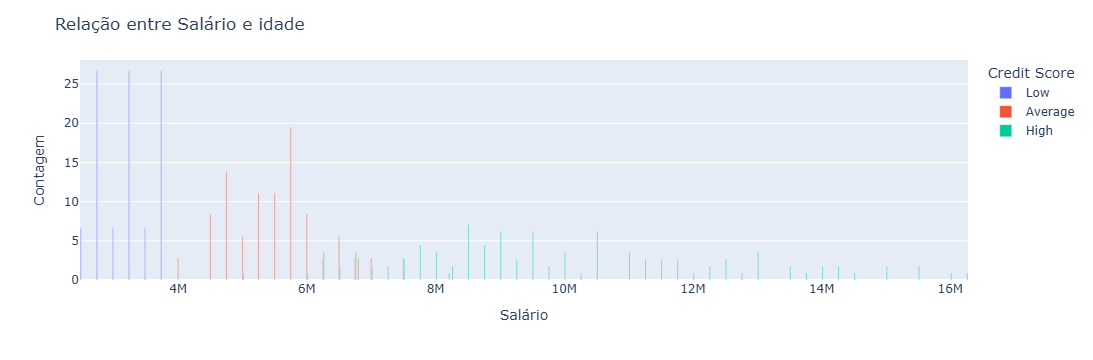

In [ ]:
# D) Salário e Score de Credito
df_grouped = df.groupby(['Income', 'Credit Score']).size().reset_index(name='count')
total_por_idade = df_grouped.groupby('Credit Score')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_idade) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Income', y='percent', color='Credit Score', barmode='group',
             labels={'Income': 'Salário', 'percent': 'Porcentagem', 'Credit Score': 'Score de Credito'})

fig.update_layout(title='Relação entre Salário e idade',
                  yaxis_title='Contagem',
                  legend_title='Credit Score')
fig.show()

### Também existe uma relação bem forte que quanto maior o salario maior o score de credito

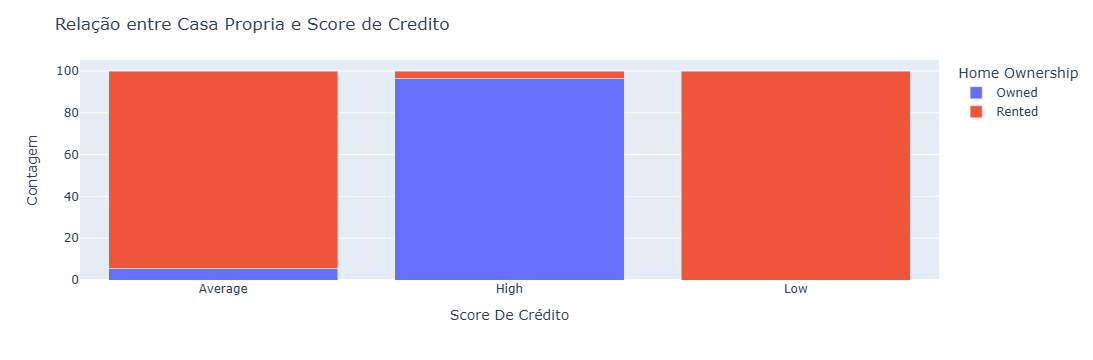

In [29]:
# E) Casa propria e Score de Credito

df_grouped = df.groupby(['Home Ownership', 'Credit Score']).size().reset_index(name='count')
total_por_casa_propria = df_grouped.groupby('Credit Score')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_casa_propria) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Credit Score', y='percent', color='Home Ownership', barmode='stack',
             labels={'Credit Score': 'Score De Crédito', 'percent': 'Porcentagem', 'Home Ownership': 'Situação Imobiliaria'})

fig.update_layout(title='Relação entre Casa Propria e Score de Credito',
                  yaxis_title='Contagem',
                  legend_title='Home Ownership')
fig.show()

### Aqui também notamos que a maior parcela das pessoas que possuem um score de crédito alto também possuem uma casa propria

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

**Qual a relação da escolaridade com a casa propria?**

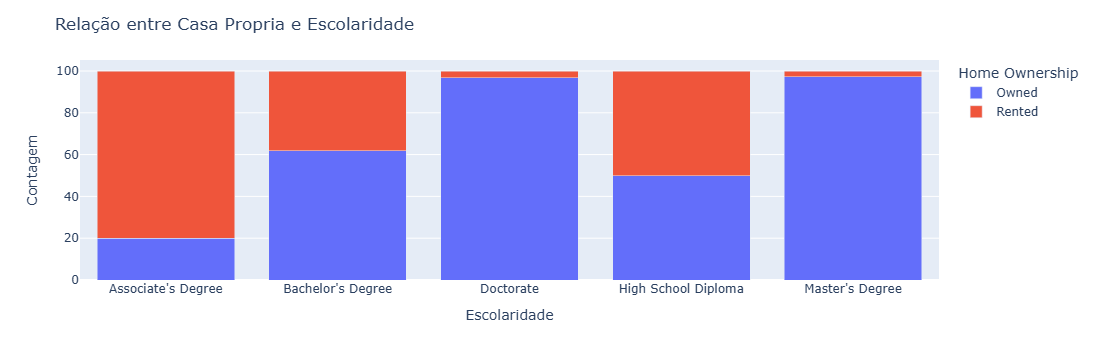

In [30]:
# seu código aqui
# Relação da casa propria com a Escolaridade
df_grouped = df.groupby(['Home Ownership', 'Education']).size().reset_index(name='count')
total_por_casa_propria = df_grouped.groupby('Education')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_casa_propria) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Education', y='percent', color='Home Ownership', barmode='stack',
             labels={'Education': 'Escolaridade', 'percent': 'Porcentagem', 'Home Ownership': 'Situação Imobiliaria'})

fig.update_layout(title='Relação entre Casa Propria e Escolaridade',
                  yaxis_title='Contagem',
                  legend_title='Home Ownership')
fig.show()

**Podemos notar que a maioria das pessoas com maior escolaridade também possui casa propria**

**Qual a relação do numero de filhos com a renda?**

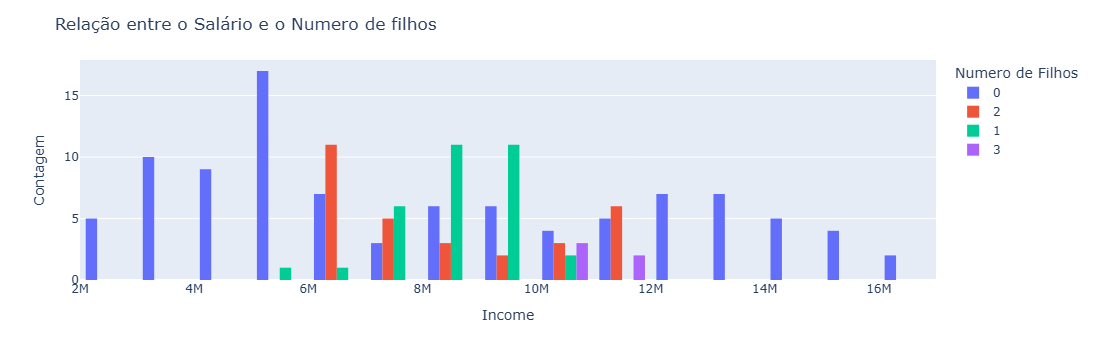

In [31]:
# Relação renda e numero de filhos

fig = px.histogram(df, x='Income', color='Number of Children', barmode='group')

fig.update_layout(title='Relação entre o Salário e o Numero de filhos',
                  xaxis_title='Income',
                  yaxis_title='Contagem',
                  legend_title='Numero de Filhos')

fig.show()

**Neste grafico notamos que a renda está concentrada nas pessoas que possuem apenas 1 filho**

**Qual a relação de filhos com o grau de escolaridade?**

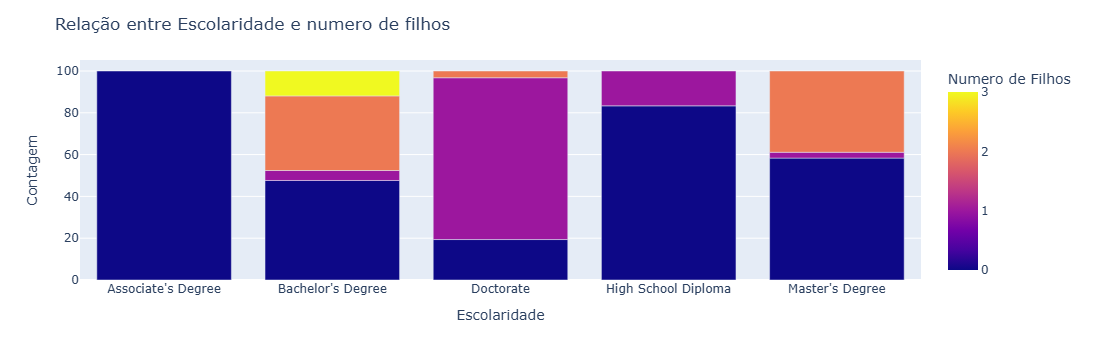

In [32]:
df_grouped = df.groupby(['Number of Children', 'Education']).size().reset_index(name='count')
total_por_educacao = df_grouped.groupby('Education')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_educacao) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Education', y='percent', color='Number of Children', barmode='stack',
             labels={'Education': 'Escolaridade', 'percent': 'Porcentagem', 'Number of Children': 'Numero de Filhos'})

fig.update_layout(title='Relação entre Escolaridade e numero de filhos',
                  yaxis_title='Contagem',
                  legend_title='Numero de filhos')
fig.show()

**Podemos perceber que existe uma grande concentração de pessoas com apenas 1 filho em uma escolaridade maior**

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

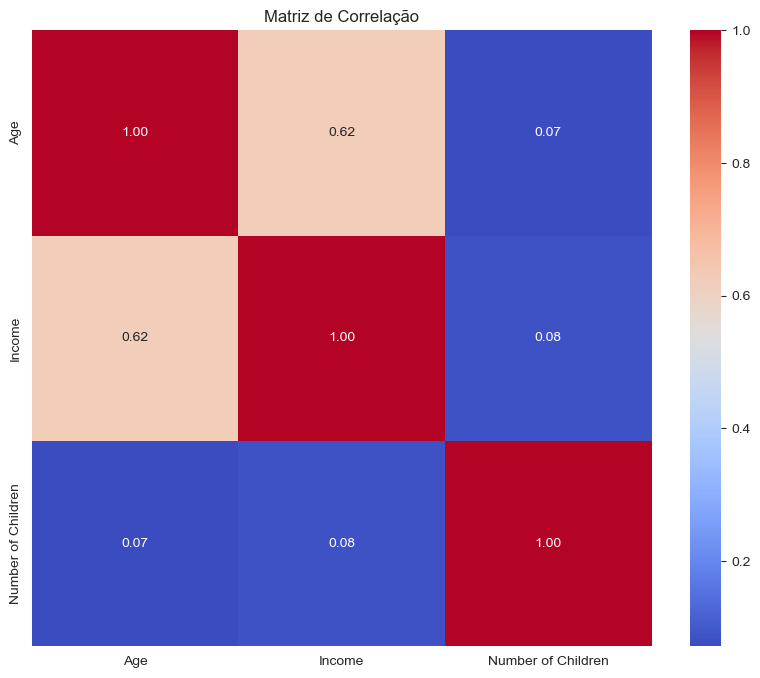

In [33]:
#seu código aqui
# Plotando o gráfico da matriz

correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

In [34]:
# sua justificativa aqui
As variéveis com correlação mais alta foram idade com o salário, o que faz sentido porque nesse dataframe o salário aumenta a medida que a idade aumenta

SyntaxError: invalid syntax (630710429.py, line 2)

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [35]:
#seu código aqui
#Plotando novamente o head só para consulta
df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,5000000.0,Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,10000000.0,Master's Degree,Married,2,Owned,High
2,35.0,Female,7500000.0,Doctorate,Married,1,Owned,High
3,40.0,Male,12500000.0,High School Diploma,Single,0,Owned,High
4,45.0,Female,10000000.0,Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,15000000.0,Master's Degree,Married,0,Owned,High
6,26.0,Female,4000000.0,Associate's Degree,Single,0,Rented,Average
7,31.0,Male,6000000.0,Bachelor's Degree,Single,0,Rented,Average
8,37.0,Female,8000000.0,Master's Degree,Married,2,Owned,High
9,37.0,Male,10500000.0,Doctorate,Single,0,Owned,High


In [ ]:
# De Variaveis categoricas temos Nivel de educação, estado civil, home owenership e score de credito
from sklearn.preprocessing import LabelEncoder

# One-Hot Encoding para as outras variáveis
df_encoded = pd.get_dummies(df,
                            columns=['Marital Status', 'Home Ownership', 'Gender', 'Education'],
                            drop_first=True,
                            dtype=int)

print(df_encoded.head())

    Age      Income  Number of Children Credit Score  Marital Status_Single  \
0  25.0   5000000.0                   0         High                      1   
1  30.0  10000000.0                   2         High                      0   
2  35.0   7500000.0                   1         High                      0   
3  40.0  12500000.0                   0         High                      1   
4  45.0  10000000.0                   3         High                      0   

   Home Ownership_Rented  Gender_Male  Education_Bachelor's Degree  \
0                      1            0                            1   
1                      0            1                            0   
2                      0            0                            0   
3                      0            1                            0   
4                      0            0                            1   

   Education_Doctorate  Education_High School Diploma  \
0                    0                         

**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

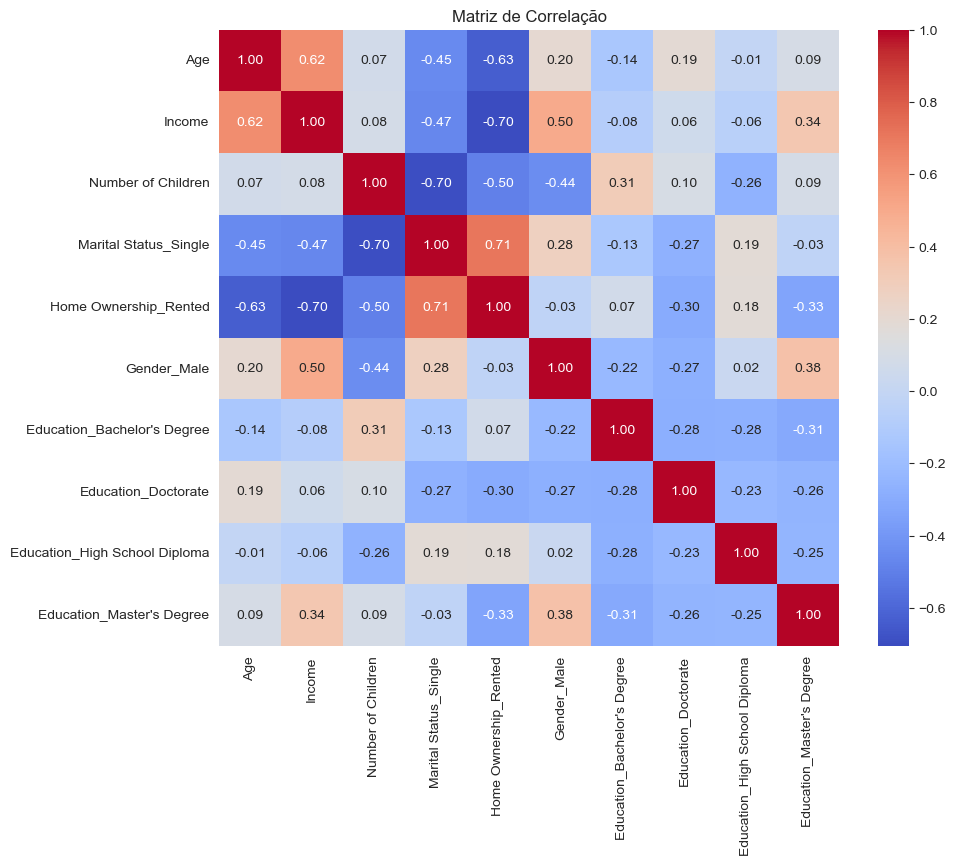

In [37]:
#seu código aqui
correlation_matrix = df_encoded.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

**Agora conseguimos notar mais correlações fortes entre, pessoas que tem o credit score alto e o salário, entre pessoas que são solteiras e possuem casas alugadas também notamos fortes correlaçoes negativas entre pessoas solteiras e numero de filhos tambpem entre pessoas que possuem um alto score de credito e casas alugadas**

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [38]:
y = df_encoded['Credit Score']
X = df_encoded.drop(['Credit Score'], axis=1)

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [40]:
X_train

,Age,Income,Number of Children,Marital Status_Single,Home Ownership_Rented,Gender_Male,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
141,26.0,4500000.0,0,1,1,0,0,0,0,0
117,29.0,2750000.0,0,1,1,0,0,0,1,0
93,25.0,6250000.0,0,1,1,0,1,0,0,0
133,29.0,6800000.0,2,0,0,0,0,1,0,0
36,31.0,6500000.0,0,1,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
71,46.0,9750000.0,1,0,0,0,0,0,1,0
106,32.0,5750000.0,0,1,1,1,0,0,0,0
14,37.0,7000000.0,2,0,0,0,1,0,0,0
92,37.0,8500000.0,1,0,0,0,0,1,0,0


In [41]:
X_test

,Age,Income,Number of Children,Marital Status_Single,Home Ownership_Rented,Gender_Male,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
135,25.0,5500000.0,0,1,1,0,1,0,0,0
115,48.0,8750000.0,1,0,0,0,0,1,0,0
131,26.0,5500000.0,1,0,0,0,1,0,0,0
55,39.0,6250000.0,2,0,0,0,1,0,0,0
95,35.0,9000000.0,1,0,0,0,0,1,0,0
29,25.0,5500000.0,0,1,1,0,1,0,0,0
157,48.0,8250000.0,1,0,0,0,0,1,0,0
51,48.0,8250000.0,1,0,0,0,0,1,0,0
101,36.0,9500000.0,2,0,0,0,0,0,0,1
145,37.0,9500000.0,1,0,0,0,0,0,1,0


In [42]:
y_train

141    Average
117        Low
93     Average
133    Average
36     Average
        ...   
71        High
106    Average
14        High
92        High
102       High
Name: Credit Score, Length: 123, dtype: object

In [43]:
y_test

135    Average
115       High
131    Average
55        High
95        High
29     Average
157       High
51        High
101       High
145       High
19     Average
85         Low
15        High
66        High
24         Low
30        High
132       High
105        Low
152       High
16        High
75        High
18         Low
12         Low
9         High
31        High
155       High
98        High
56        High
134       High
160    Average
139       High
78        High
60        High
84        High
2         High
94        High
45        High
42     Average
69        High
153        Low
26        High
Name: Credit Score, dtype: object

In [44]:
print("Tamanho de X_train:", X_train.shape)

Tamanho de X_train: (123, 10)


In [45]:
print("Tamanho do X_test:",X_test.shape)

Tamanho do X_test: (41, 10)


In [46]:
print("Tamanho do y_train:",y_train.shape)

Tamanho do y_train: (123,)


In [47]:
print("Tamanho do y_test:",y_test.shape)

Tamanho do y_test: (41,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

<Axes: xlabel='Credit Score'>

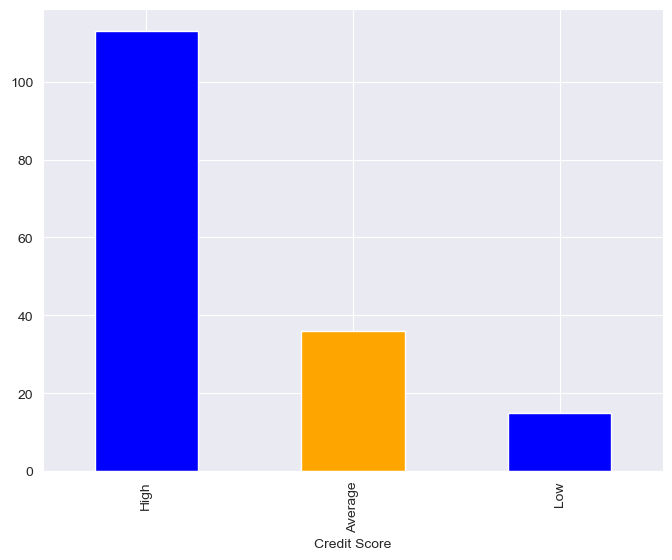

In [48]:
#seu código aqui
credit_score_counts = df['Credit Score'].value_counts()
plt.figure(figsize=(8, 6))
credit_score_counts.plot(kind='bar', color=['blue', 'orange'])

**A muito mais pessoas com o credit score alto do que pessoas com o credit score baixo ou mediano, acredito que seria mais simples nivelarmos pelo credit score alto**

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [49]:
from imblearn.over_sampling import SMOTE

# Criar uma instância do SMOTE
smote = SMOTE(random_state=42)

# Aplicar o SMOTE aos dados de treinamento (X_train, y_train)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Verificar a distribuição das classes após o balanceamento
print("Distribuição das classes após o balanceamento:")
print(y_train_balanced.value_counts())

Distribuição das classes após o balanceamento:
Credit Score
Average    84
Low        84
High       84
Name: count, dtype: int64


In [51]:
y_train.to_csv('y_train_balanced.csv', index=False)

In [52]:
X_train.to_csv('X_train_balanced.csv', index=False)

In [53]:
y_test.to_csv('y_test.csv', index=False)

In [54]:
X_test.to_csv('X_test.csv', index=False)